# Méthode de Newton — Corrigé du TP5

In [1]:
import numpy as np
from numpy.linalg import norm, solve
import matplotlib.pyplot as plt
from math import pi, sqrt

## Exercice 1 — Intersection d'ellipses

On cherche à déterminer l'intersection des ellipses d'équations $x^2 + \frac{1}{2}y^2 = 1$ et $y^2 + \frac{1}{2}x^2 = 1$.

### Tracé des ellipses

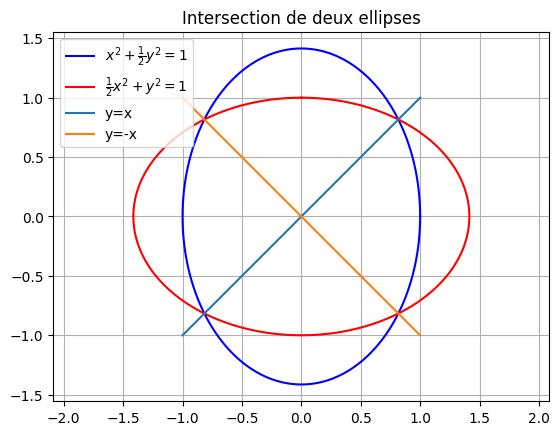

In [2]:
theta = np.linspace(0, 2*pi, 200)

# Ellipse 1 : x^2 + y^2/2 = 1  =>  x = cos(t), y = sqrt(2)*sin(t)
xe1 = np.cos(theta)
ye1 = sqrt(2) * np.sin(theta)

# Ellipse 2 : y^2 + x^2/2 = 1  =>  x = sqrt(2)*sin(t), y = cos(t)
xe2 = sqrt(2) * np.sin(theta)
ye2 = np.cos(theta)

plt.figure()
plt.plot(xe1, ye1, 'b', label=r'$x^2 + \frac{1}{2}y^2 = 1$')
plt.plot(xe2, ye2, 'r', label=r'$\frac{1}{2}x^2 + y^2 = 1$')
plt.axis('equal')
plt.grid(True)
plt.title('Intersection de deux ellipses')
plt.plot([-1, 1], [-1, 1], label='y=x')
plt.plot([-1, 1], [1, -1], label='y=-x')
plt.legend(loc='upper left')
plt.show()

### Méthode de Newton

Il s'agit d'annuler la fonction $F:\mathbb{R}^2\rightarrow \mathbb{R}^2$ définie par
$$F(x,y) = \begin{pmatrix} x^2 + \frac{1}{2}y^2 - 1 \\ y^2 + \frac{1}{2}x^2 - 1 \end{pmatrix}$$

dont la matrice jacobienne est
$$JF(x,y) = \begin{pmatrix} 2x & y \\ x & 2y \end{pmatrix}$$

In [3]:
def F1(v):
    x, y = v
    return np.array([x**2 + 0.5*y**2 - 1,
                     0.5*x**2 + y**2 - 1])

def JF1(v):
    x, y = v
    return np.array([[2*x, y],
                     [x, 2*y]])

def Newton(F, JF, x0, Tol=1e-8, IterMax=100):
    """
    Méthode de Newton pour résoudre F(x) = 0.
    F  : R^n -> R^n
    JF : jacobienne de F
    x0 : point initial dans R^n
    Sortie : x (solution), cvg (bool), iter (nb itérations)
    """
    x = x0.copy()
    Fx = F(x)
    JFx = JF(x)
    d = solve(JFx, Fx)
    it = 0
    while norm(d) > Tol and it < IterMax:
        x = x - d
        Fx = F(x)
        JFx = JF(x)
        d = solve(JFx, Fx)
        it += 1
    cvg = norm(d) <= Tol
    return x, cvg, it

### Test avec 4 initialisations

Par symétrie, les 4 solutions sont $(\pm\sqrt{2/3}, \pm\sqrt{2/3})$. On choisit une initialisation dans chaque quadrant.

x0 = [1. 1.] => solution = [0.81649658 0.81649658], cvg = True, iter = 4
x0 = [-1.  1.] => solution = [-0.81649658  0.81649658], cvg = True, iter = 4
x0 = [-1. -1.] => solution = [-0.81649658 -0.81649658], cvg = True, iter = 4
x0 = [ 1. -1.] => solution = [ 0.81649658 -0.81649658], cvg = True, iter = 4


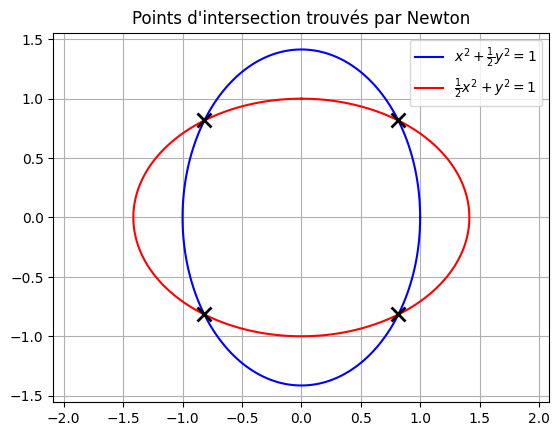

In [4]:
initialisations = [np.array([1.0, 1.0]),
                   np.array([-1.0, 1.0]),
                   np.array([-1.0, -1.0]),
                   np.array([1.0, -1.0])]

plt.figure()
plt.plot(xe1, ye1, 'b', label=r'$x^2 + \frac{1}{2}y^2 = 1$')
plt.plot(xe2, ye2, 'r', label=r'$\frac{1}{2}x^2 + y^2 = 1$')
plt.axis('equal')
plt.grid(True)

for x0 in initialisations:
    sol, cvg, niter = Newton(F1, JF1, x0)
    print(f"x0 = {x0} => solution = {sol}, cvg = {cvg}, iter = {niter}")
    plt.plot(sol[0], sol[1], 'kx', markersize=10, markeredgewidth=2)

plt.legend()
plt.title('Points d\'intersection trouvés par Newton')
plt.show()

---

## Exercice 2 — Gradient à pas optimal (variante de Newton)

On considère la fonction $f(v) = (v_1 - 4)^2 + 2(v_2 - 3)^2 + v_1 v_2$ et on utilise une variante de Newton (méthode de la sécante) pour déterminer le pas optimal à chaque itération de la méthode du gradient.

### Définition de $f$ et de son gradient

In [5]:
def f(v):
    return (v[0] - 4)**2 + 2*(v[1] - 3)**2 + v[0]*v[1]

def gradf(x):
    return np.array([2*(x[0] - 4) + x[1],
                     4*(x[1] - 3) + x[0]])

def gprime(rho, gradf, x):
    """Dérivée de g_n(rho) = f(x - rho * gradf(x)) par rapport à rho."""
    return -np.dot(gradf(x - rho*gradf(x)), gradf(x))

### Variante de Newton (méthode de la sécante)

On approche $g_n''(\varrho_k)$ par le taux d'accroissement avec $\delta = 10^{-8}$ :

$$\varrho_{k+1} = \varrho_k - \delta \frac{g_n'(\varrho_k)}{g_n'(\varrho_k + \delta) - g_n'(\varrho_k)}$$

In [6]:
def varnewton(gprime, gradf, x, rho0, eps=1e-5, Nmax=100):
    """
    Variante de Newton (sécante) pour résoudre gprime(rho) = 0.
    Retourne (rho_optimal, nb_iterations).
    """
    rho = rho0
    delta = 1e-8
    n = 0
    while abs(gprime(rho, gradf, x)) > eps and n < Nmax:
        gp = gprime(rho, gradf, x)
        rho = rho - delta * gp / (gprime(rho + delta, gradf, x) - gp)
        n += 1
    return rho, n

In [7]:
# Methode de Newton parallelisable pour z^3 = 1 en complexe.

### Test de `varnewton`

Avec $x = 0_{\mathbb{R}^2}$, $\varrho_0 = 1$, $\varepsilon = 10^{-5}$, $N_{\max} = 100$.

In [8]:
x_test = np.zeros(2)
rho_star, n_iter = varnewton(gprime, gradf, x_test, rho0=1.0, eps=1e-5, Nmax=100)
print(f"rho* = {rho_star:.8f}, nb itérations = {n_iter}")

rho* = 0.23214285, nb itérations = 1


### Comparaison avec la valeur théorique

Pour une forme quadratique $f(v) = \frac{1}{2}\langle Av, v\rangle + \langle b, v\rangle$, le pas optimal est :
$$\rho_{\text{opt}} = \frac{\|Av + b\|^2}{\langle Av + b,\, A(Av + b)\rangle}$$

Ici $A = \begin{pmatrix} 2 & 1 \\ 1 & 4 \end{pmatrix}$ et $b = \begin{pmatrix} -8 \\ -12 \end{pmatrix}$.

In [9]:
A = np.array([[2, 1], [1, 4]])
b = np.array([-8, -12])
v = np.zeros(2)
grad = A.dot(v) + b
rho_opt = norm(grad)**2 / np.dot(grad, A.dot(grad))
print(f"rho_opt théorique = {rho_opt:.8f}")
print(f"rho* Newton       = {rho_star:.8f}")
print(f"Erreur relative   = {abs(rho_star - rho_opt)/rho_opt:.2e}")

rho_opt théorique = 0.23214286
rho* Newton       = 0.23214285
Erreur relative   = 2.01e-08


### Gradient à pas optimal

In [10]:
def gradient_optimal(gradf, gprime, x0, rho0, eps=1e-6,
                     eps_Newton=1e-6, Nmax=500, Nmax_Newton=100):
    """
    Méthode du gradient à pas optimal.
    Retourne : (x_min, n_grad, n_newton_total, liste_itérés)
    """
    x = x0.copy()
    xlist = [x.copy()]
    n = 0
    Nnew_total = 0
    alpha = rho0
    while norm(gradf(x)) > eps and n < Nmax:
        alpha, n_newton = varnewton(gprime, gradf, x, alpha,
                                    eps_Newton, Nmax_Newton)
        x = x - alpha * gradf(x)
        n += 1
        xlist.append(x.copy())
        Nnew_total += n_newton
    return x, n, Nnew_total, np.array(xlist)

### Nombre d'itérations en fonction de $\varrho_0$

On fait varier $\varrho_0$ entre 0.01 et 1 par pas de 0.01, avec :
$$v_0 = (1,1),\; \varepsilon = 10^{-6},\; N_{\max} = 500,\; \varepsilon_{\text{Newton}} = 10^{-6},\; N_{\max,\text{Newton}} = 10.$$

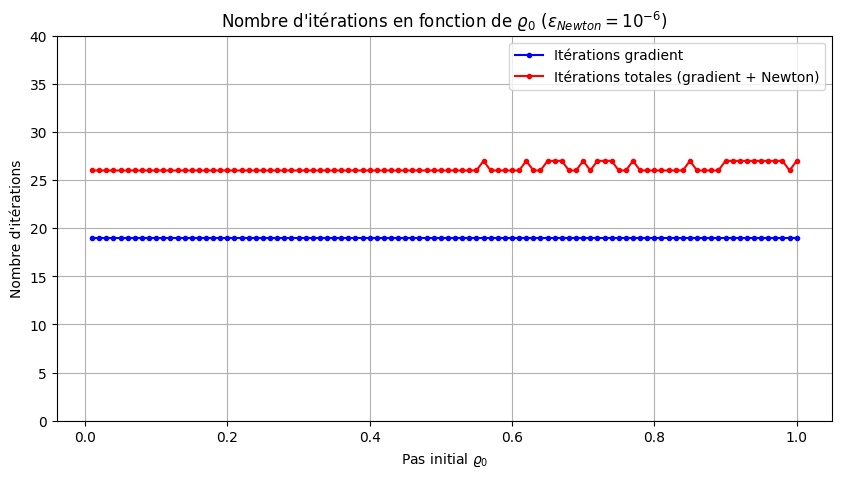

In [11]:
rho0_values = np.arange(0.01, 1.01, 0.01)
N_grad = np.zeros(len(rho0_values))
N_total = np.zeros(len(rho0_values))

for i, rho0 in enumerate(rho0_values):
    x0 = np.array([1.0, 1.0])
    _, ng, nnewt, _ = gradient_optimal(gradf, gprime, x0, rho0,
                                       eps=1e-6, eps_Newton=1e-6,
                                       Nmax=500, Nmax_Newton=10)
    N_grad[i] = ng
    N_total[i] = ng + nnewt

plt.figure(figsize=(10, 5))
plt.plot(rho0_values, N_grad, 'b.-', label='Itérations gradient')
plt.plot(rho0_values, N_total, 'r.-', label='Itérations totales (gradient + Newton)')
plt.xlabel(r'Pas initial $\varrho_0$')
plt.ylabel("Nombre d'itérations")
plt.title(r"Nombre d'itérations en fonction de $\varrho_0$ ($\varepsilon_{Newton} = 10^{-6}$)")
plt.legend()
plt.grid(True)
plt.ylim(0, 40)
plt.show()

### Même graphique avec $\varepsilon_{\text{Newton}} = 10^{-12}$

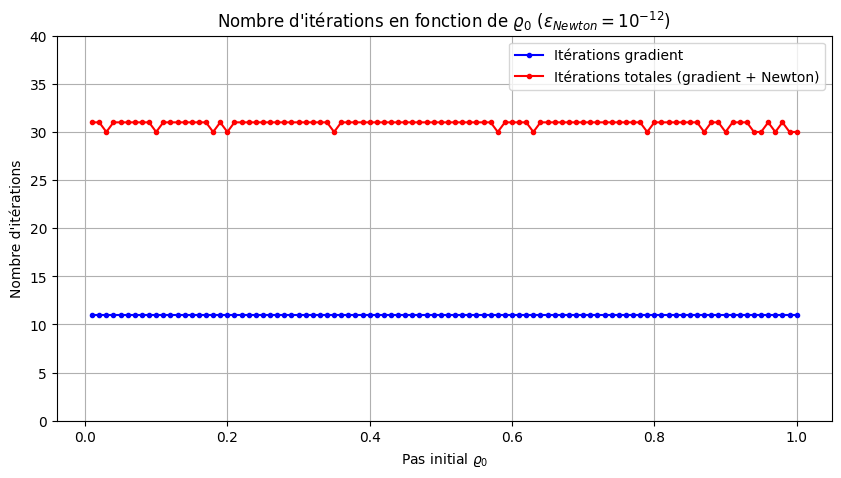

In [12]:
N_grad2 = np.zeros(len(rho0_values))
N_total2 = np.zeros(len(rho0_values))

for i, rho0 in enumerate(rho0_values):
    x0 = np.array([1.0, 1.0])
    _, ng, nnewt, _ = gradient_optimal(gradf, gprime, x0, rho0,
                                       eps=1e-6, eps_Newton=1e-12,
                                       Nmax=500, Nmax_Newton=10)
    N_grad2[i] = ng
    N_total2[i] = ng + nnewt

plt.figure(figsize=(10, 5))
plt.plot(rho0_values, N_grad2, 'b.-', label='Itérations gradient')
plt.plot(rho0_values, N_total2, 'r.-', label='Itérations totales (gradient + Newton)')
plt.xlabel(r'Pas initial $\varrho_0$')
plt.ylabel("Nombre d'itérations")
plt.title(r"Nombre d'itérations en fonction de $\varrho_0$ ($\varepsilon_{Newton} = 10^{-12}$)")
plt.legend()
plt.grid(True)
plt.ylim(0, 40)
plt.show()

**Commentaire** : Le nombre d'itérations du gradient est quasi-pas fixe quel que soit $\varrho_0$ (typiquement autour de 2-3 itérations). C'est parce que Newton converge très vite vers le pas optimal, donc le gradient à pas optimal se comporte de manière très régulière. Avec $\varepsilon_{\text{Newton}} = 10^{-12}$, Newton a besoin de plus d'itérations internes, mais le nombre d'itérations du gradient reste le même.

### Comparaison : lignes de niveau, gradient pas fixe vs gradient optimal

Gradient optimal  : 11 itérations (+ 20 Newton)
Gradient pas fixe : 54 itérations


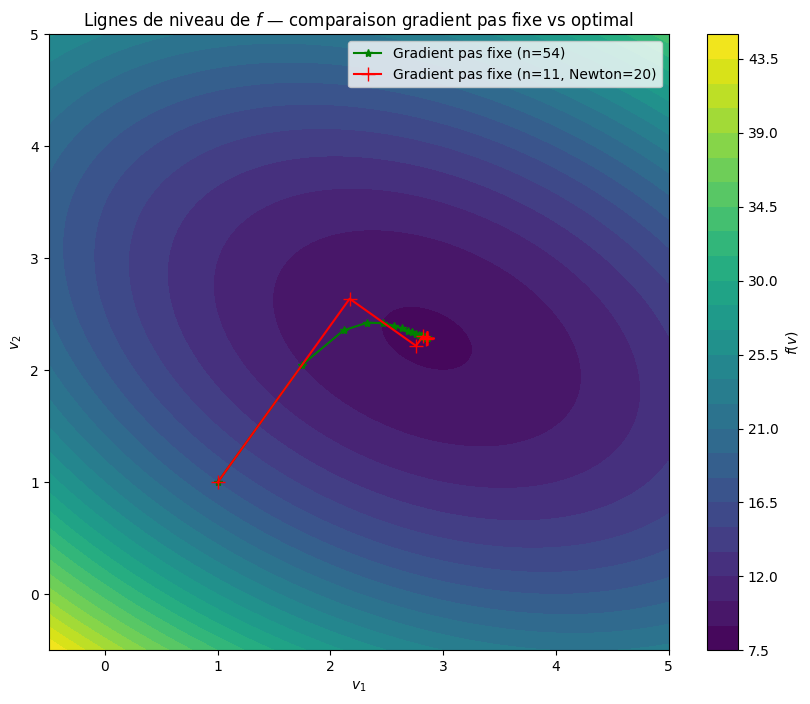

In [20]:
def gradient_pas_fixe(gradf, x0, alpha, eps=1e-6, Nmax=500):
    """Méthode du gradient à pas constant."""
    x = x0.copy()
    xlist = [x.copy()]
    n = 0
    while norm(gradf(x)) > eps and n < Nmax:
        x = x - alpha * gradf(x)
        n += 1
        xlist.append(x.copy())
    return x, n, np.array(xlist)

x0 = np.array([1.0, 1.0])
al0 = 0.15

xopt, nopt, noptnewt, xoptlist = gradient_optimal(gradf, gprime, x0, al0, eps_Newton=1e-12)
xcst, ncst, xcstlist = gradient_pas_fixe(gradf, x0, al0)

print(f"Gradient optimal  : {nopt} itérations (+ {noptnewt} Newton)")
print(f"Gradient pas fixe : {ncst} itérations")

xg = np.linspace(-0.5, 5, 200)
yg = np.linspace(-0.5, 5, 200)
X, Y = np.meshgrid(xg, yg)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = f(np.array([X[i, j], Y[i, j]]))

plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(label='$f(v)$')
plt.plot(xcstlist[:, 0], xcstlist[:, 1], 'g*-',
         label=f'Gradient pas fixe (n={ncst})', markersize=6)
plt.plot(xoptlist[:, 0], xoptlist[:, 1], 'r+-',
         label=f'Gradient pas fixe (n={nopt}, Newton={noptnewt})', markersize=10)
plt.xlabel('$v_1$')
plt.ylabel('$v_2$')
plt.title('Lignes de niveau de $f$ — comparaison gradient pas fixe vs optimal')
plt.legend()
plt.show()

---

## Exercice 3 — Positionnement GPS

On cherche à déterminer la position $(x, y, z)$ d'un récepteur et le biais d'horloge $w = c\Delta t$ en résolvant :

$$F_i(v) = \sqrt{(X_i - x)^2 + (Y_i - y)^2 + (Z_i - z)^2} + w - m_i = 0, \quad i \in \{1,2,3,4\}$$

### Données des satellites

In [21]:
pos1 = [5000000, 3632713, 19021130]
m1 = 14777408

pos2 = [-5000000, 15388418, 11755705]
m2 = 19200781

pos3 = [11180340, 3632713, -16180340]
m3 = 22461519

pos4 = [9510565, 6909830, 16180339]
m4 = 14367732

Xi = np.array([pos1[0], pos2[0], pos3[0], pos4[0]], dtype=float)
Yi = np.array([pos1[1], pos2[1], pos3[1], pos4[1]], dtype=float)
Zi = np.array([pos1[2], pos2[2], pos3[2], pos4[2]], dtype=float)
mi = np.array([m1, m2, m3, m4], dtype=float)

mesures = (Xi, Yi, Zi, mi)

### Implémentation de $F$

In [22]:
def F_gps(v, mesures):
    Xi, Yi, Zi, mi = mesures
    x, y, z, w = v[..., 0], v[..., 1], v[..., 2], v[..., 3]
    dist = np.sqrt((Xi - x[..., None])**2 + (Yi - y[..., None])**2 + (Zi - z[..., None])**2)
    return dist + w[..., None] - mi

print("F(0) =", F_gps(np.zeros(4), mesures))

F(0) = [ 5222591.75543172   799219.21474372 -2461518.78071078  5632267.18507613]


### Calcul et implémentation de la Jacobienne

On a :
$$\frac{\partial F_i}{\partial x} = \frac{-(X_i - x)}{d_i}, \quad
\frac{\partial F_i}{\partial y} = \frac{-(Y_i - y)}{d_i}, \quad
\frac{\partial F_i}{\partial z} = \frac{-(Z_i - z)}{d_i}, \quad
\frac{\partial F_i}{\partial w} = 1$$

avec $d_i = \sqrt{(X_i - x)^2 + (Y_i - y)^2 + (Z_i - z)^2}$.

In [23]:
def JF_gps(v, mesures):
    Xi, Yi, Zi, mi = mesures
    x, y, z, w = v
    J = np.zeros((4, 4))
    for i in range(4):
        di = np.sqrt((Xi[i] - x)**2 + (Yi[i] - y)**2 + (Zi[i] - z)**2)
        J[i, 0] = (x - Xi[i]) / di
        J[i, 1] = (y - Yi[i]) / di
        J[i, 2] = (z - Zi[i]) / di
        J[i, 3] = 1.0
    return J

print("JF(0) =")
print(JF_gps(np.zeros(4), mesures))

JF(0) =
[[-0.25       -0.18163565 -0.95105651  1.        ]
 [ 0.25       -0.76942089 -0.58778524  1.        ]
 [-0.55901699 -0.18163565  0.80901699  1.        ]
 [-0.47552827 -0.34549151 -0.80901698  1.        ]]


### Newton pour le GPS

In [24]:
def Newton_gps(F, JF, v0, Tol, IterMax, mesures):
    """
    Méthode de Newton pour F(v) = 0 (avec paramètre mesures).
    Retourne : v (solution), S (liste itérés), cvg (bool), it (nb itérations)
    """
    v = v0.copy()
    S = [v.copy()]
    it = 0
    Fv = F(v, mesures)
    while norm(Fv) > Tol and it < IterMax:
        JFv = JF(v, mesures)
        d = solve(JFv, Fv)
        v = v - d
        Fv = F(v, mesures)
        it += 1
        S.append(v.copy())
    cvg = norm(Fv) <= Tol
    return v, S, cvg, it

### Résolution

Avec $v_0 = (0,0,0,0)$ et une tolérance de $10^{-4}$.

In [25]:
v0 = np.zeros(4)
v_sol, S, cvg, niter = Newton_gps(F_gps, JF_gps, v0, Tol=1e-4, IterMax=100, mesures=mesures)

print(f"Convergence : {cvg} en {niter} itérations")
print(f"Position du récepteur : x = {v_sol[0]:.1f} m, y = {v_sol[1]:.1f} m, z = {v_sol[2]:.1f} m")
print(f"Biais w = c*Δt = {v_sol[3]:.1f} m")

c = 2.9979e8
delta_t = v_sol[3] / c
print(f"Décalage d'horloge Δt = {delta_t:.6e} s = {delta_t*1e6:.2f} µs")
print(f"Distance du récepteur au centre de la Terre : {norm(v_sol[:3]):.0f} m")
print(f"Rayon de la Terre : 6371000 m")

Convergence : True en 4 itérations
Position du récepteur : x = 4199999.9 m, y = 171999.5 m, z = 4780000.2 m
Biais w = c*Δt = 99999.6 m
Décalage d'horloge Δt = 3.335656e-04 s = 333.57 µs
Distance du récepteur au centre de la Terre : 6365374 m
Rayon de la Terre : 6371000 m


### Visualisation 3D 

NOTA: Les visualisations 3D matplotlib ne sont pas optimales...
On trace la Terre, les satellites et le récepteur.

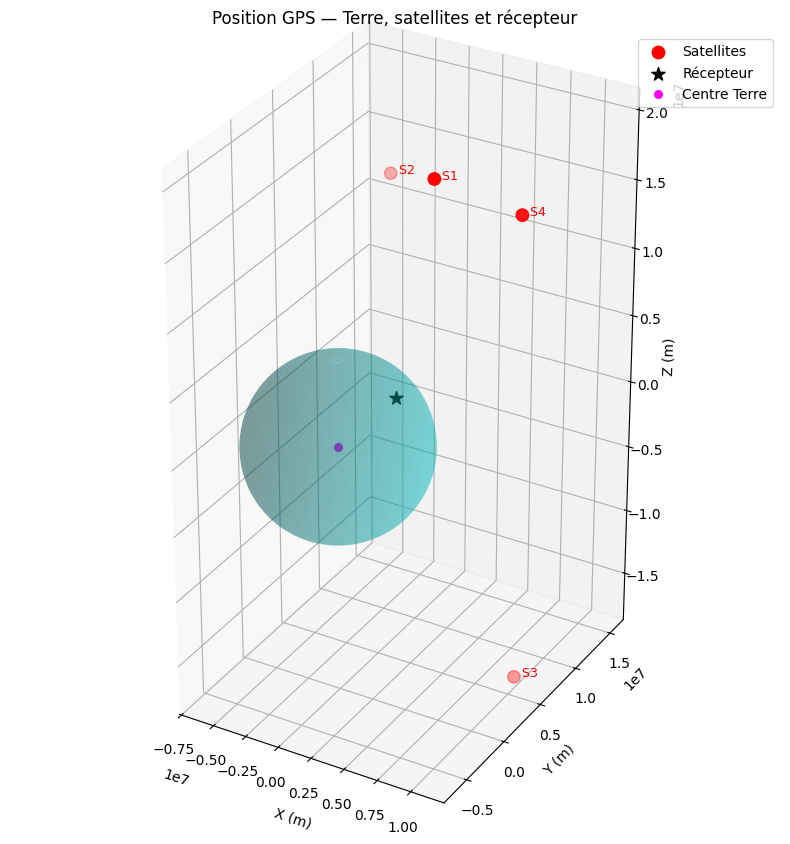

In [26]:
def Sphere(r):
    phi, theta = np.mgrid[0.0:np.pi:100j, 0.0:2.0*np.pi:100j]
    xt = r * np.sin(phi) * np.cos(theta)
    yt = r * np.sin(phi) * np.sin(theta)
    zt = r * np.cos(phi)
    return xt, yt, zt

r_terre = 6371000.0
xt, yt, zt = Sphere(r_terre)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(xt, yt, zt, color='c', alpha=0.3, linewidth=0)

ax.scatter(Xi, Yi, Zi, color='red', s=80, label='Satellites')
for i in range(4):
    ax.text(Xi[i], Yi[i], Zi[i], f'  S{i+1}', fontsize=9, color='red')

ax.scatter(v_sol[0], v_sol[1], v_sol[2], color='black', s=100,
           marker='*', label='Récepteur')
ax.scatter(0, 0, 0, color='magenta', s=30, label='Centre Terre')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_aspect('equal')

ax.legend()
ax.set_title('Position GPS — Terre, satellites et récepteur')
plt.show()

## Newton fractal — attracteurs de $z^3 = 1$

Les trois racines cubiques de l'unité sont :
$$z_0 = 1, \quad z_1 = e^{2i\pi/3}, \quad z_2 = e^{4i\pi/3}$$

On applique Newton à $f(z) = z^3 - 1$ (donc $f'(z) = 3z^2$) sur une grille de points complexes dans $[-2,2]^2$.
Chaque pixel est coloré selon la racine vers laquelle Newton converge.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grille de points complexes dans [-2, 2] x [-2, 2]
N = 800
x = np.linspace(-2, 2, N)
y = np.linspace(-2, 2, N)
Z = x[np.newaxis, :] + 1j * y[:, np.newaxis]   # shape (N, N)

# Les 3 racines de z^3 = 1
roots = np.array([1, np.exp(2j * np.pi / 3), np.exp(4j * np.pi / 3)])

# Newton vectorisé : z_{n+1} = z_n - f(z_n)/f'(z_n) = z_n - (z^3-1)/(3z^2) = (2z^3 + 1) / (3z^2)
Tol = 1e-6
IterMax = 50

Z0 = Z.copy()
attractor = np.full(Z.shape, -1, dtype=int)   # -1 = pas encore convergé
niter = np.zeros(Z.shape, dtype=int)

for it in range(IterMax):
    denom = 3 * Z0**2
    # Eviter la division par zéro à l'origine
    safe = np.abs(denom) > 1e-14
    Z0 = np.where(safe, (2 * Z0**3 + 1) / denom, Z0)

    # Pour les points pas encore attribués, vérifier convergence
    for k, r in enumerate(roots):
        converged = (np.abs(Z0 - r) < Tol) & (attractor == -1)
        attractor[converged] = k
        niter[converged] = it + 1

    if np.all(attractor != -1):
        break

# Image : couleur = racine, luminosité = vitesse de convergence
colors = np.array([[0.2, 0.5, 1.0],   # bleu  -> racine 0
                   [1.0, 0.3, 0.2],   # rouge -> racine 1
                   [0.2, 0.8, 0.3]])  # vert  -> racine 2

img = np.zeros((N, N, 3))
for k in range(3):
    mask = attractor == k
    shade = 1 - 0.6 * (niter[mask] / IterMax)   # plus clair = convergence rapide
    img[mask] = shade[:, np.newaxis] * colors[k]

# Points non convergés en noir
img[attractor == -1] = 0.0

plt.figure(figsize=(8, 8))
plt.imshow(img, extent=[-2, 2, -2, 2], origin='lower')

# Marquer les 3 racines
for k, r in enumerate(roots):
    plt.plot(r.real, r.imag, 'w*', markersize=14, markeredgecolor='k',
             label=f'$z_{k}$', zorder=5)

plt.title("Fractale de Newton — attracteurs de $z^3 = 1$", fontsize=14)
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()